In [ ]:
from xsdba.adjustment import QuantileDeltaMapping
import xarray as xr
from xclim.indices import tx_days_above
from dask.diagnostics.progress import ProgressBar
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from ibicus.debias import ISIMIP
from indicator_delta_scaling import threshold as th
from time import perf_counter


HIST_PERIOD = ("1991", "2010")
FUT_PERIOD = ("2015", "2100")
BARCELONA = {"longitude": [2.17], "latitude": [41.39]}

variables = ["tasmax", "pr", "hurs", "sfcWind", "tas"]
models = [
    "KACE-1-0-G_r1i1p1f1",
    "ACCESS-CM2_r1i1p1f1",
    "NorESM2-MM_r1i1p1f1",
    "INM-CM5-0_r1i1p1f1",
    "INM-CM4-8_r1i1p1f1",
    "CMCC-ESM2_r1i1p1f1",
    "MIROC-ES2L_r1i1p1f2",
    "MRI-ESM2-0_r1i1p1f1",
]

save_path = Path("/prod1/benchmarks/")

# Prepare data
Save variable data as NetCDFs for a single location in Barcelona. Convert all calendars to 360-day.

In [ ]:
with ProgressBar():
    for i, variable in enumerate(variables, 1):
        print(f"{variable} ({i}/{len(variables)})")
        ref = xr.open_zarr(f"/prod1/regrid/era5-coarsened/{variable}.zarr")[
            variable
        ].sel(time=slice(*HIST_PERIOD))
        ref = ref.convert_calendar("360_day", align_on="year")
        ref = ref.assign_coords(time=[t.replace(hour=12) for t in ref.time.values])
        ref.sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
            save_path / f"era5/{variable}_era5_barcelona.nc",
            mode="w",
            encoding={variable: {"dtype": "float32"}},
        )
        for model in models:
            hist = xr.open_zarr(
                f"/prod1/regrid/cmip6/historical/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*HIST_PERIOD))
            rcp45 = xr.open_zarr(
                f"/prod1/regrid/cmip6/rcp45/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*FUT_PERIOD))
            rcp85 = xr.open_zarr(
                f"/prod1/regrid/cmip6/rcp85/{variable}/{variable}_{model}.zarr"
            )[variable].sel(time=slice(*FUT_PERIOD))
            if hist.time.dt.calendar != "360_day":
                hist = hist.convert_calendar("360_day", align_on="year")
                rcp45 = rcp45.convert_calendar("360_day", align_on="year")
                rcp85 = rcp85.convert_calendar("360_day", align_on="year")
            hist.sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"historical/{variable}_hist_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )
            rcp45.sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"rcp45/{variable}_rcp45_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )
            rcp85.sel(**BARCELONA, method="nearest").chunk(time=-1).to_netcdf(
                save_path / f"rcp85/{variable}_rcp85_{model}_barcelona.nc",
                encoding={variable: {"dtype": "float32"}},
            )


tasmax (1/5)
[########################################] | 100% Completed | 880.51 ms
[########################################] | 100% Completed | 311.05 ms
[########################################] | 100% Completed | 1.33 sms
[########################################] | 100% Completed | 1.14 sms
[########################################] | 100% Completed | 408.59 ms
[########################################] | 100% Completed | 1.61 sms
[########################################] | 100% Completed | 1.15 sms
[########################################] | 100% Completed | 313.75 ms
[########################################] | 100% Completed | 1.38 sms
[########################################] | 100% Completed | 1.18 sms
[########################################] | 100% Completed | 409.92 ms
[########################################] | 100% Completed | 1.25 sms
[########################################] | 100% Completed | 1.15 sms
[########################################] | 100% Completed

## Load data
Loads Barcelona data into two dictionaries for projections and reference.

In [ ]:
references = {
    variable: xr.open_dataset(save_path / f"era5/{variable}_era5_barcelona.nc")[
        variable
    ]
    for variable in variables
}

cmip6 = {
    "historical": {
        variable: {
            model: xr.open_dataset(
                save_path / f"historical/{variable}_hist_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
    "rcp45": {
        variable: {
            model: xr.open_dataset(
                save_path / f"rcp45/{variable}_rcp45_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
    "rcp85": {
        variable: {
            model: xr.open_dataset(
                save_path / f"rcp85/{variable}_rcp85_{model}_barcelona.nc"
            )[variable]
            for model in models
        }
        for variable in variables
    },
}

## Configs for flexible method testing
These configs should make testing different indicator configurations easier.


In [ ]:
config_tx30_single = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp45"],
    "models": ["CMCC-ESM2_r1i1p1f1"],
    "periods": [("2051", "2070")],
    "indicator_func": lambda tasmax: tx_days_above(tasmax, thresh="30 degC"),
}

config_tx30_all = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp45", "rcp85"],
    "models": models,
    "periods": [
        ("2021", "2040"),
        ("2031", "2050"),
        ("2041", "2060"),
        ("2051", "2070"),
        ("2061", "2080"),
    ],
    "indicator_func": lambda tasmax: tx_days_above(tasmax, thresh="30 degC"),
}


## Quantile Delta Mapping

Implement and test indicator computation with Quantile Delta Mapping (QDM).

In [ ]:
def qdm_adjust(ref, hist, fut):
    qdm = QuantileDeltaMapping.train(
        ref=ref, hist=hist.isel(scenario=0, drop=True), nquantiles=30, kind="+"
    )
    # qdm.ds = qdm.ds.persist()
    hist_adj = qdm.adjust(hist)
    fut_adj = qdm.adjust(fut)
    return hist_adj.transpose(*list(hist.dims)), fut_adj.transpose(*list(fut.dims))


def compute_with_qdm(config):
    adj_start = perf_counter()
    adjusted = {
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }
    # Adjust all variables for all models
    for variable in config["variables"]:
        ref = references[variable]
        for model in config["models"]:
            hist = cmip6["historical"][variable][model]
            qdm = QuantileDeltaMapping.train(
                ref=ref,
                hist=hist.isel(scenario=0, drop=True),
                nquantiles=30,
                kind=config["kind"],
            )
            adjusted["historical"][model][variable] = qdm.adjust(hist)

            for scenario in config["scenarios"]:
                fut = cmip6[scenario][variable][model]

                fut_adj = []
                for period in config["periods"]:
                    fut_adj.append(
                        qdm.adjust(fut.sel(time=slice(*period)))
                        .expand_dims(period=[f"{period[0]}-{period[1]}"])
                        .assign_coords(time=hist.time.values)
                    )
                adjusted[scenario][model][variable] = xr.concat(fut_adj, dim="period")

    adj_end = perf_counter()
    adj_time = adj_end - adj_start

    indicator_start = perf_counter()
    # Compute indicators for all models
    for model in config["models"]:
        ind_hist = config["indicator_func"](**adjusted["historical"][model])
        for scenario in config["scenarios"]:
            ind_fut = config["indicator_func"](**adjusted[scenario][model])

    indicator_end = perf_counter()

    return adj_time, indicator_end - indicator_start


### Time QDM

In [ ]:
data = []
for i in range(1, 11):
    total_start = perf_counter()
    adj_time, indicator_time = compute_with_qdm(config_tx30_single)
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {"total": total, "adjustment_time": adj_time, "indicator_time": indicator_time}
    )


qdm_df = pd.DataFrame(data)
qdm_df.to_csv(save_path / "qdm_dtx30_single.csv", index=False)

## ISIMIP bias adjustment
Implement and time indicator computation with ISIMIP bias adjustment.

In [ ]:
def isimimp_adjust(ref, hist, fut):
    isimip_tasmax = ISIMIP.from_variable("tas")
    isimip_order = ["time", "longitude", "latitude"]
    ref_values = ref.transpose(*isimip_order).values
    hist_values = (
        hist.isel(scenario=0, realization=0, drop=True).transpose(*isimip_order).values
    )
    fut_values = (
        fut.isel(scenario=0, realization=0, drop=True).transpose(*isimip_order).values
    )

    return xr.DataArray(
        isimip_tasmax.apply(ref_values, hist_values, fut_values),
        dims=("time", "latitude", "longitude"),
        coords={"time": fut.time, "latitude": fut.latitude, "longitude": fut.longitude},
        name=fut.name,
        attrs=fut.attrs,
    )


def compute_with_isimip(config):
    adj_start = perf_counter()
    adjusted = {
        scenario: {
            model: {variable: {} for variable in config["variables"]}
            for model in config["models"]
        }
        for scenario in ["historical", *config["scenarios"]]
    }

    for variable in config["variables"]:
        ref = references[variable]
        for model in config["models"]:
            hist = cmip6["historical"][variable][model]
            adjusted["historical"][model][variable] = isimimp_adjust(ref, hist, hist)

            for scenario in config["scenarios"]:
                fut = cmip6[scenario][variable][model]

                fut_adj = []
                for period in config["periods"]:
                    fut_adj.append(
                        isimimp_adjust(ref, hist, fut.sel(time=slice(*period)))
                        .expand_dims(period=[f"{period[0]}-{period[1]}"])
                        .assign_coords(time=hist.time.values)
                    )
                adjusted[scenario][model][variable] = xr.concat(fut_adj, dim="period")

    adj_end = perf_counter()
    adj_time = adj_end - adj_start

    indicator_start = perf_counter()

    for model in config["models"]:
        ind_hist = config["indicator_func"](**adjusted["historical"][model])
        for scenario in config["scenarios"]:
            ind_fut = config["indicator_func"](**adjusted[scenario][model])

    indicator_end = perf_counter()

    return adj_time, indicator_end - indicator_start


### Time ISIMIP

In [ ]:
data = []
for i in range(1, 11):
    print(i)
    total_start = perf_counter()
    adj_time, indicator_time = compute_with_isimip(config_tx30_single)
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {"total": total, "adjustment_time": adj_time, "indicator_time": indicator_time}
    )


isimip_df = pd.DataFrame(data)

isimip_df.to_csv(save_path / "isimip_dtx30_single.csv")

## Indicator Delta Scaling
Implement and time indicator computation with Indicator Delta Scaling (IDS).
The configs need to be slightly changed because of the flexible `indicator_func`.

In [ ]:
config_tx30_all = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp45", "rcp85"],
    "models": models,
    "periods": [
        ("2021", "2040"),
        ("2031", "2050"),
        ("2041", "2060"),
        ("2051", "2070"),
        ("2061", "2080"),
    ],
    "indicator_func": tx_days_above,
}

config_tx30_single = {
    "kind": "+",
    "variables": ["tasmax"],
    "scenarios": ["rcp85"],
    "models": models[:1],
    "periods": [("2051", "2070")],
    "indicator_func": tx_days_above,
}


def compute_with_ids(config):
    variable = "tasmax"
    ref = references[variable]
    threshold_time = 0
    indicator_time = 0
    delta_time = 0
    ind_ref_start = perf_counter()
    ind_ref = config["indicator_func"](ref, thresh="30 degC")
    indicator_time += perf_counter() - ind_ref_start

    for model in config["models"]:
        threshold_start = perf_counter()
        hist = cmip6["historical"][variable][model]

        threshold = th.get_absolute_threshold(
            ref, hist.sel(scenario="historical"), 30, "degC", "absolute"
        ).compute()

        threshold_time += perf_counter() - threshold_start

        indicator_hist_start = perf_counter()
        ind_hist = config["indicator_func"](hist, thresh=threshold)
        indicator_time += perf_counter() - indicator_hist_start

        for scenario in config["scenarios"]:
            indicator_fut_start = perf_counter()
            fut = cmip6[scenario][variable][model]

            ind_fut = []
            for period in config["periods"]:
                ind_fut.append(
                    config["indicator_func"](
                        fut.sel(time=slice(*period)), thresh=threshold
                    )
                    .expand_dims(period=[f"{period[0]}-{period[1]}"])
                    .assign_coords(time=ind_hist.time.values)
                )
            ind_fut = xr.concat(ind_fut, dim="period")

            indicator_time += perf_counter() - indicator_fut_start

            delta_start = perf_counter()
            ind_fut_adj = ind_ref + (ind_fut - ind_hist.sel(scenario="historical"))
            delta_time += perf_counter() - delta_start

    return threshold_time, indicator_time, delta_time


### Time IDS

In [ ]:
data = []
for i in range(1, 11):
    print(i)
    total_start = perf_counter()
    threshold_time, indicator_time, delta_time = compute_with_ids(config_tx30_single)
    total_end = perf_counter()
    total = total_end - total_start
    data.append(
        {
            "total": total,
            "threshold_time": threshold_time,
            "indicator_time": indicator_time,
            "delta_time": delta_time,
        }
    )

df = pd.DataFrame(data)

df.to_csv(save_path / "ids_dtx30_single.csv", index=False)

## Plot different methods
Plotting the different methods in a stacked bar chart.

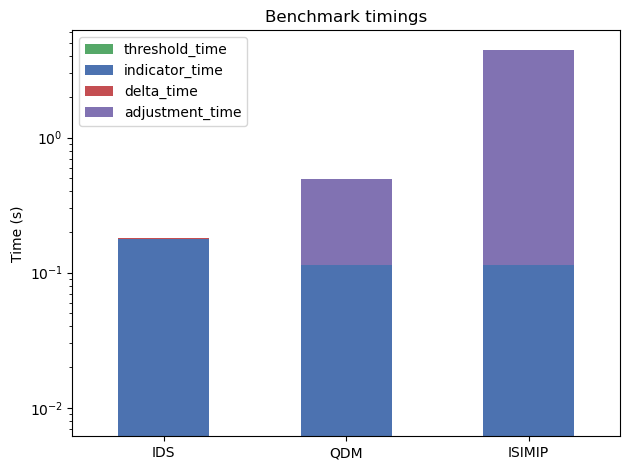

In [ ]:
ids = pd.read_csv(save_path / "ids_dtx30_single.csv")
qdm = pd.read_csv(save_path / "qdm_dtx30_single.csv")
isimip = pd.read_csv(save_path / "isimip_dtx30_single.csv")

means = pd.DataFrame(
    {
        "IDS": [
            ids["threshold_time"].mean(),
            ids["indicator_time"].mean(),
            ids["delta_time"].mean(),
            0,
        ],
        "QDM": [0, qdm["indicator_time"].mean(), 0, qdm["adjustment_time"].mean()],
        "ISIMIP": [
            0,
            isimip["indicator_time"].mean(),
            0,
            isimip["adjustment_time"].mean(),
        ],
    },
    index=["threshold_time", "indicator_time", "delta_time", "adjustment_time"],
)

colors = ["#55A868", "#4C72B0", "#C44E52", "#8172B2"]

fig, ax = plt.subplots()
means.T.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_yscale("log")
ax.set_ylabel("Time (s)")
ax.set_title("Benchmark timings")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
